# Laboratorio 1 — Series de Tiempo
## Bloque 1: carga, limpieza, split y construcción de series (Esteban)

CC3084 — Data Science, Semestre II 2026.

Este notebook ejecuta de punta a punta el pipeline de:
1. Carga y validación de la base cruda.
2. Limpieza de inconsistencias conocidas.
3. Split temporal 70/30 (train/test).
4. Construcción de las series de tiempo mensuales.

No incluye EDA con gráficos (bloque de Hugo) ni análisis de las series (bloque de Ernesto).

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from carga import cargar_base
from limpieza import limpiar_base, validar_calidad
from series import generar_series, FECHA_INICIO, FECHA_FIN, FECHA_FIN_TRAIN

RUTA_RAW = "../data/raw/Base_Migracion_2009-2026jun.xlsx"
RUTA_PROCESSED = "../data/processed"
RUTA_SERIES = "../data/processed/series"
RUTA_FIGURAS = "../informe/figuras"

## 1. Carga de la base

In [2]:
df_raw = cargar_base(RUTA_RAW)
print("Shape:", df_raw.shape)
print("Meses únicos:", df_raw["fecha"].nunique())
print("Rango:", df_raw["fecha"].min(), "a", df_raw["fecha"].max())
df_raw.head()

Shape: (161036, 14)
Meses únicos: 210
Rango: 2009-01-01 00:00:00 a 2026-06-01 00:00:00


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


**Notas de la hoja `Notas` del Excel (resumen):**

- Los datos son solo para uso académico; no son cifras oficiales de INGUAT ni del Instituto Guatemalteco de Migración.
- Cobertura: enero 2009 a junio 2026, 210 meses consecutivos, 161,036 registros, sin huecos.
- Formato largo: una fila por combinación de mes, vía, frontera, país/agrupación y tipo de viajero. Sin filas de total ni doble conteo.
- Tres tramos de fuente con distinta metodología: 2009-2020 (respaldos históricos), 2021-2022 (entrega IGM), 2023-jun 2026 (sistema depurado INGUAT). Los niveles no son perfectamente comparables entre tramos, en particular el quiebre 2022→2023 en `Tipo de Viajero` (ver sección de decisiones más abajo).
- Desde 2023 la columna `País` reporta por agrupación de mercado (27 grupos) en vez de país individual (226 países hasta 2022); los mercados principales siguen siendo comparables.
- Vía Marítima pierde detalle desde 2017 (cambio de registro).

## 2. Limpieza

In [3]:
df = limpiar_base(df_raw)
checks = validar_calidad(df)
checks

{'n_nulos': 0,
 'n_duplicados_exactos': 0,
 'n_viajero_con_decimales': 51272,
 'n_viajero_cero': 54,
 'fronteras_no_numeradas': ['Cruceros']}

**Problemas detectados y resueltos** (valores originales conservados en columnas `_raw`):

| Problema | Resolución |
|---|---|
| `Región dos`: "Cruceristas" (2009-2021) y "Cruceros" (2022) son la misma categoría | Unificados en `"Cruceros"` |
| `Región dos`: valor basura `"0"` (2022, 821 viajeros) | Reetiquetado como `"Sin especificar"` |
| `País`: duplicados por casing (ej. `"OTROS PAISES DEL MUNDO"` vs `"Otros Paises Del Mundo"`, y 12 casos adicionales del mismo tipo detectados por código) | Unificados a la variante con más registros |
| `Regiones OMT`: valores basura `"0x2a"` y `"SIN ESPECIFICAR"` | Unificados en `"Sin especificar"` |
| `Frontera`: `"Cruceros"` aparece como si fuera una frontera, junto a `"22 Otra frontera"` | Se deja igual, queda documentado aquí |
| `Viajero`: 51,272 registros con decimales (estimaciones/prorrateos) y 54 valores en exactamente 0 | No se redondea; queda documentado aquí |

Cero nulos y cero duplicados exactos confirmados por código arriba.

## 3. Decisiones fijadas

In [4]:
total_general = df["Viajero"].sum()
total_guatemala = df.loc[df["País"] == "Guatemala", "Viajero"].sum()
print(f"Guatemala acumula {total_guatemala:,.0f} viajeros ({total_guatemala/total_general:.1%} del total)")

top3_sin_guatemala = (
    df.loc[df["País"] != "Guatemala"].groupby("País")["Viajero"].sum().sort_values(ascending=False).head(3)
)
top3_sin_guatemala

Guatemala acumula 14,792,331 viajeros (28.3% del total)


País
El Salvador                  1.621398e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
Name: Viajero, dtype: float64

**Decisión — `País == "Guatemala"`:** acumula ~14.8M viajeros (28% del total). Son residentes
retornando, no viajeros internacionales entrantes. Se **mantienen en la serie total** (para no
alterar el total oficial), pero se **excluyen del ranking de países de residencia**. El Top 3 de
países de residencia queda: **El Salvador, Estados Unidos de América, Honduras**.

**Decisión — 2026 es un año parcial:** solo cubre enero-junio 2026. No es comparable en totales
anuales contra los demás años; cualquier comparación anual debe advertir esto.

**Decisión — `Tipo de Viajero`:** tiene 4 valores (Turista, Excursionista, Viajero, Cruceristas).
Entre 2022 y 2023 la categoría "Viajero" cae fuertemente (~1.06M a ~0.33M) por un cambio de
criterio metodológico (exclusión de comercio fronterizo y tránsito), no por una caída real de
turismo. Para comparar visitantes durante todo el período conviene usar Turista + Excursionista,
que son consistentes en toda la serie.

## 4. Split temporal 70/30

In [5]:
meses = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="MS")
meses_train = pd.date_range(FECHA_INICIO, FECHA_FIN_TRAIN, freq="MS")
meses_test = meses.difference(meses_train)

print(f"Total de meses: {len(meses)}")
print(f"Train: {meses_train.min().date()} a {meses_train.max().date()} ({len(meses_train)} meses, {len(meses_train)/len(meses):.1%})")
print(f"Test:  {meses_test.min().date()} a {meses_test.max().date()} ({len(meses_test)} meses, {len(meses_test)/len(meses):.1%})")

Total de meses: 210
Train: 2009-01-01 a 2021-03-01 (147 meses, 70.0%)
Test:  2021-04-01 a 2026-06-01 (63 meses, 30.0%)


**El corte 2021-03 / 2021-04 no es arbitrario:** deja la caída de la pandemia (colapso desde
marzo 2020, piso 2020-2021 en ~27% del nivel de 2019) **dentro del conjunto de entrenamiento**, y
la **recuperación completa posterior a 2022 queda en el conjunto de prueba**. Esto es intencional
y debe justificarse en el informe: el modelo entrena viendo el shock y su fondo, pero es evaluado
prediciendo una recuperación con una dinámica distinta a la de la caída.

## 5. Construcción de series

In [6]:
series = generar_series(df, RUTA_SERIES)
print("Series generadas y guardadas en", RUTA_SERIES)
sorted(series.keys())

Series generadas y guardadas en ../data/processed/series


['pais_el_salvador',
 'pais_el_salvador_train',
 'pais_estados_unidos',
 'pais_estados_unidos_train',
 'pais_honduras',
 'pais_honduras_train',
 'total',
 'total_train',
 'via_aerea',
 'via_aerea_train',
 'via_maritima',
 'via_maritima_train',
 'via_terrestre',
 'via_terrestre_train']

In [7]:
import os
os.makedirs(RUTA_PROCESSED, exist_ok=True)
df.to_csv(os.path.join(RUTA_PROCESSED, "base_limpia.csv"), index=False)
print("base_limpia.csv guardado:", df.shape)

base_limpia.csv guardado: (161036, 17)


## 6. Verificación visual de la serie total

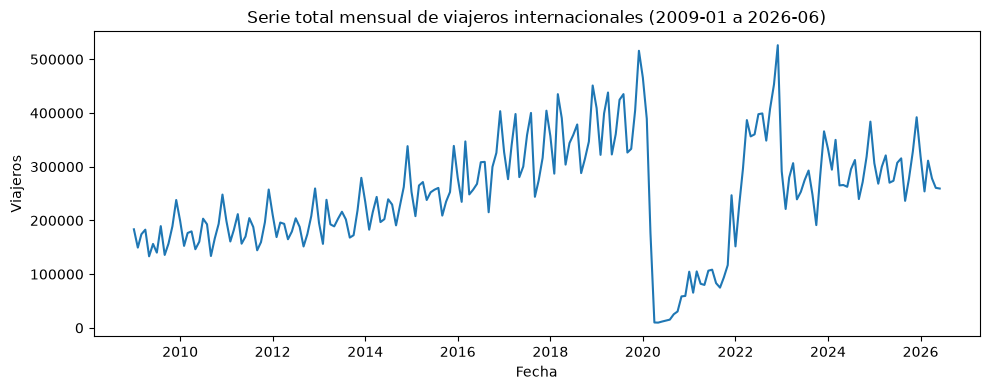

In [8]:
fechas = pd.to_datetime(series["total"]["fecha"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fechas, series["total"]["viajeros"])
ax.set_title("Serie total mensual de viajeros internacionales (2009-01 a 2026-06)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "serie_total.png"), dpi=150)
plt.show()

**Resumen de validaciones ejecutadas:**
- Shape de la base cruda: 161,036 × 13 ✓
- 210 meses únicos, 2009-01 a 2026-06, sin huecos ✓
- Cero nulos, cero duplicados exactos tras limpieza ✓
- Suma de las 3 series por vía == serie total (verificado por código en `generar_series`) ✓
- 7 series + sus versiones train guardadas en `data/processed/series/` ✓